# Breast Ultrasound Classification

In [ ]:
%pip install -q albumentations opencv-python-headless

In [ ]:
import os
import cv2
import json
import shutil
import numpy as np
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import torchvision.models as models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

data_root = '/content/drive/MyDrive/BUSI'
split_file = os.path.join(data_root, 'data_split_85_15.json')
save_root = '/content/drive/MyDrive/BUSI1'
os.makedirs(save_root, exist_ok=True)

model_prefix = 'class_2'
main_model_path = os.path.join(save_root, f'{model_prefix}.pth')

def fold_model_path(fold):
    return os.path.join(save_root, f'{model_prefix}_fold_{fold+1}.pth')

Mounted at /content/drive


In [ ]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

device: cuda


## Training Configuration

In [ ]:
config = {
    'input_size': 256,
    'batch_size': 16,
    'num_epochs': 100,
    'num_workers': 8,
    'lr': 1e-4,
    'weight_decay': 1e-4,
    'lr_patience': 4,
    'lr_factor': 0.5,
    'early_stopping_patience': 15,
    'n_folds': 5,
}

## Load Data

In [ ]:
with open(split_file, 'r', encoding='utf-8') as f:
    data_split = json.load(f)

dev_images = data_split['development']
test_images = data_split['test']

dev_paths = [img['path'] for img in dev_images]
dev_labels = [img['label'] for img in dev_images]
test_paths = [img['path'] for img in test_images]
test_labels = [img['label'] for img in test_images]

dev_pairs = sorted(zip(dev_paths, dev_labels))
test_pairs = sorted(zip(test_paths, test_labels))
dev_paths_sorted = [p for p, _ in dev_pairs]
dev_labels_sorted = [l for _, l in dev_pairs]
test_paths_sorted = [p for p, _ in test_pairs]
test_labels_sorted = [l for _, l in test_pairs]

print(f'dev: {len(dev_paths_sorted)} | test: {len(test_paths_sorted)}')

dev: 663 | test: 117


## Dataset

In [ ]:
class CropDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.label_map = {'normal': 0, 'benign': 1, 'malignant': 2}

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f'image not found: {image_path}')

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']

        label = self.label_map[self.labels[idx]]
        return image, torch.tensor(label, dtype=torch.long)

## Augmentation

In [ ]:
train_transform = A.Compose([
    A.Resize(config['input_size'], config['input_size']),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.10, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(p=0.15),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(config['input_size'], config['input_size']),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## Model

In [ ]:
def build_model():
    model = models.resnet34(weights='DEFAULT')
    num_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(num_features, 256),
        nn.ReLU(inplace=True),
        nn.Dropout(0.2),
        nn.Linear(256, 3),
    )
    return model

## Loss Function

In [ ]:
criterion = nn.CrossEntropyLoss()

## Training Functions

In [ ]:
def safe_auc_multiclass(y_true, y_prob, n_classes=3):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    if len(np.unique(y_true)) < 2:
        return float('nan')
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))
    return roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_probs = []
    all_labels = []
    all_preds = []
    use_amp = device.type == 'cuda'
    amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
            logits = model(images)
            loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        probs = torch.softmax(logits, dim=1).float().detach().cpu().numpy()
        preds = np.argmax(probs, axis=1)
        running_loss += loss.item() * images.size(0)
        all_probs.extend(probs.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())
        all_preds.extend(preds.tolist())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = safe_auc_multiclass(all_labels, all_probs, n_classes=3)
    epoch_acc = (np.array(all_preds) == np.array(all_labels)).mean()
    return epoch_loss, epoch_auc, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_probs = []
    all_labels = []
    all_preds = []
    use_amp = device.type == 'cuda'
    amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
                logits = model(images)
                loss = criterion(logits, labels)

            probs = torch.softmax(logits, dim=1).float().cpu().numpy()
            preds = np.argmax(probs, axis=1)
            running_loss += loss.item() * images.size(0)
            all_probs.extend(probs.tolist())
            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.tolist())

    all_labels_np = np.array(all_labels).astype(int)
    all_probs_np = np.array(all_probs)
    all_preds_np = np.array(all_preds)
    epoch_loss = running_loss / len(loader.dataset)
    epoch_auc = safe_auc_multiclass(all_labels_np, all_probs_np, n_classes=3)
    epoch_acc = (all_preds_np == all_labels_np).mean()

    return epoch_loss, epoch_auc, epoch_acc, all_probs_np, all_labels_np, all_preds_np

In [ ]:
def train_fold(fold, train_idx, val_idx, dev_paths_sorted, dev_labels_sorted, config, device):
    train_paths = [dev_paths_sorted[i] for i in train_idx]
    train_labels = [dev_labels_sorted[i] for i in train_idx]
    val_paths = [dev_paths_sorted[i] for i in val_idx]
    val_labels = [dev_labels_sorted[i] for i in val_idx]

    train_dataset = CropDataset(train_paths, train_labels, transform=train_transform)
    val_dataset = CropDataset(val_paths, val_labels, transform=val_transform)

    train_label_ids = [train_dataset.label_map[l] for l in train_labels]
    class_counts = [max(train_label_ids.count(i), 1) for i in range(3)]
    class_weights = [sum(class_counts) / c for c in class_counts]
    sample_weights = [class_weights[label_id] for label_id in train_label_ids]
    sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        sampler=sampler,
        shuffle=False,
        num_workers=config['num_workers'],
        pin_memory=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        num_workers=config['num_workers'],
        pin_memory=True,
    )

    model = build_model().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=config['lr_patience'],
        factor=config['lr_factor'],
    )

    best_val_loss = float('inf')
    best_val_auc = float('nan')
    best_val_acc = 0.0
    best_epoch = -1
    patience_counter = 0

    history = {
        'train_loss': [],
        'train_auc': [],
        'train_acc': [],
        'val_loss': [],
        'val_auc': [],
        'val_acc': [],
        'lr': [],
    }

    for epoch in range(config['num_epochs']):
        train_loss, train_auc, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_auc, val_acc, _, _, _ = validate(model, val_loader, criterion, device)

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(train_loss)
        history['train_auc'].append(train_auc)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        train_auc_str = f'{train_auc:.4f}' if not np.isnan(train_auc) else 'n/a'
        val_auc_str = f'{val_auc:.4f}' if not np.isnan(val_auc) else 'n/a'
        print(f'[fold {fold+1} | ep {epoch+1:03d}] loss {train_loss:.4f}/{val_loss:.4f} auc {train_auc_str}/{val_auc_str} acc {train_acc:.4f}/{val_acc:.4f} lr {current_lr:.2e}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_auc = val_auc
            best_val_acc = val_acc
            best_epoch = epoch + 1
            patience_counter = 0
            torch.save(
                {
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'best_val_loss': best_val_loss,
                    'best_val_auc': best_val_auc,
                    'best_val_acc': best_val_acc,
                    'config': config,
                    'fold': fold + 1,
                },
                fold_model_path(fold),
            )
        else:
            patience_counter += 1
            if patience_counter >= config['early_stopping_patience']:
                break

    return {
        'fold': fold,
        'best_val_loss': best_val_loss,
        'best_val_auc': best_val_auc,
        'best_val_acc': best_val_acc,
        'best_epoch': best_epoch,
        'history': history,
    }

## 5-Fold Cross Validation

In [ ]:
skf = StratifiedKFold(n_splits=config['n_folds'], shuffle=True, random_state=42)
fold_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(dev_paths_sorted, dev_labels_sorted)):
    print(f'\nFold {fold+1}/{config["n_folds"]}')
    result = train_fold(fold, train_idx, val_idx, dev_paths_sorted, dev_labels_sorted, config, device)
    fold_results.append(result)
    auc_str = f"{result['best_val_auc']:.4f}" if not np.isnan(result['best_val_auc']) else 'n/a'
    print(f"  best val loss: {result['best_val_loss']:.4f} | best val auc: {auc_str} | best val acc: {result['best_val_acc']:.4f} | epoch: {result['best_epoch']}")

best_fold = int(np.argmin([r['best_val_loss'] for r in fold_results]))
shutil.copyfile(fold_model_path(best_fold), main_model_path)

fold_losses = [r['best_val_loss'] for r in fold_results]
fold_aucs = [r['best_val_auc'] for r in fold_results]
fold_accs = [r['best_val_acc'] for r in fold_results]
print(f'\nmean best val loss: {np.mean(fold_losses):.4f} ± {np.std(fold_losses):.4f}')
print(f'mean best val auc: {np.nanmean(fold_aucs):.4f} ± {np.nanstd(fold_aucs):.4f}')
print(f'mean best val acc: {np.mean(fold_accs):.4f} ± {np.std(fold_accs):.4f}')
print(f'saved main checkpoint: {main_model_path}')


Fold 1/5
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 210MB/s]


[fold 1 | ep 001] loss 0.9836/0.9953 auc 0.6953/0.8591 acc 0.4906/0.5714 lr 1.00e-04
[fold 1 | ep 002] loss 0.6523/0.6792 auc 0.8922/0.8960 acc 0.7358/0.7744 lr 1.00e-04
[fold 1 | ep 003] loss 0.5105/0.4698 auc 0.9300/0.9384 acc 0.8094/0.8120 lr 1.00e-04
[fold 1 | ep 004] loss 0.5112/0.5654 auc 0.9297/0.9161 acc 0.8151/0.7820 lr 1.00e-04
[fold 1 | ep 005] loss 0.4359/0.5150 auc 0.9496/0.9304 acc 0.8321/0.8496 lr 1.00e-04
[fold 1 | ep 006] loss 0.4260/0.6933 auc 0.9481/0.9014 acc 0.8396/0.7293 lr 1.00e-04
[fold 1 | ep 007] loss 0.3655/0.5720 auc 0.9646/0.9366 acc 0.8547/0.8120 lr 1.00e-04
[fold 1 | ep 008] loss 0.3616/0.6861 auc 0.9625/0.9184 acc 0.8642/0.8120 lr 5.00e-05
[fold 1 | ep 009] loss 0.3619/0.5797 auc 0.9620/0.9421 acc 0.8755/0.8421 lr 5.00e-05
[fold 1 | ep 010] loss 0.2851/0.4517 auc 0.9724/0.9379 acc 0.9038/0.8647 lr 5.00e-05
[fold 1 | ep 011] loss 0.2670/0.4884 auc 0.9809/0.9364 acc 0.8925/0.8571 lr 5.00e-05
[fold 1 | ep 012] loss 0.3454/0.5012 auc 0.9659/0.9320 acc 0.8811

## Visualization

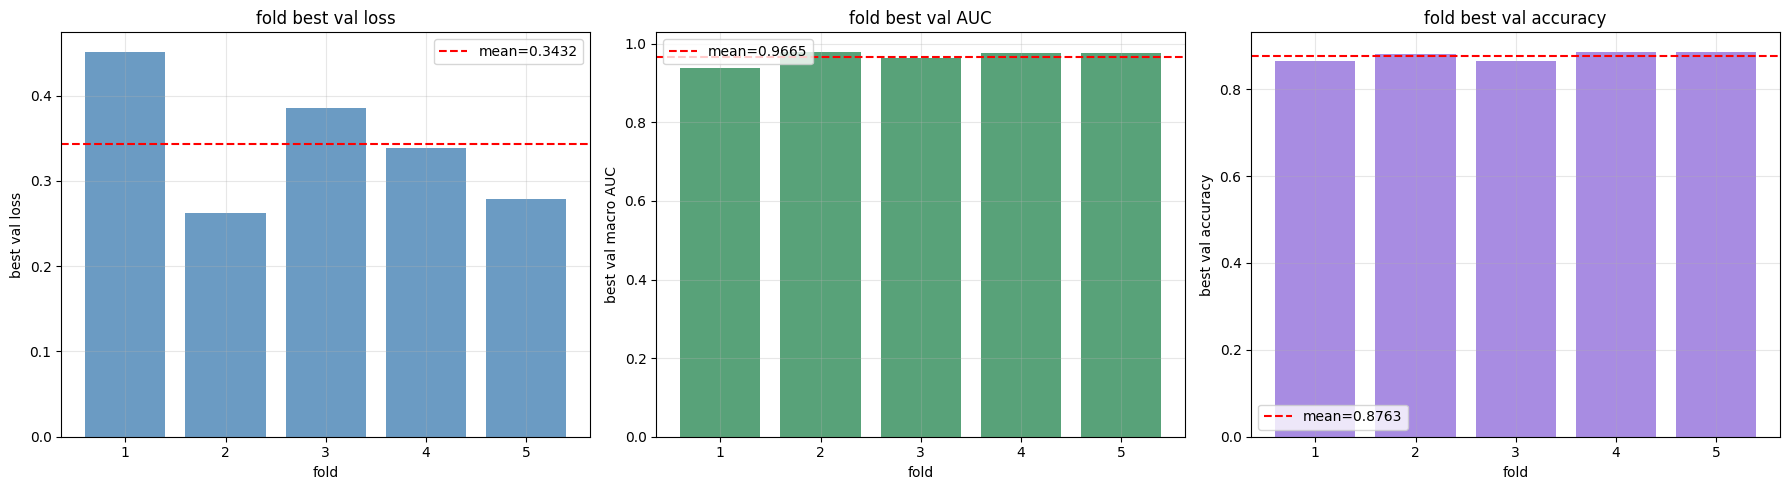

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fold_numbers = [r['fold'] + 1 for r in fold_results]
fold_losses = [r['best_val_loss'] for r in fold_results]
fold_aucs = [r['best_val_auc'] for r in fold_results]
fold_accs = [r['best_val_acc'] for r in fold_results]

axes[0].bar(fold_numbers, fold_losses, color='steelblue', alpha=0.8)
axes[0].axhline(np.mean(fold_losses), color='red', linestyle='--', label=f"mean={np.mean(fold_losses):.4f}")
axes[0].set_xlabel('fold')
axes[0].set_ylabel('best val loss')
axes[0].set_title('fold best val loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(fold_numbers, fold_aucs, color='seagreen', alpha=0.8)
axes[1].axhline(np.nanmean(fold_aucs), color='red', linestyle='--', label=f"mean={np.nanmean(fold_aucs):.4f}")
axes[1].set_xlabel('fold')
axes[1].set_ylabel('best val macro AUC')
axes[1].set_title('fold best val AUC')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].bar(fold_numbers, fold_accs, color='mediumpurple', alpha=0.8)
axes[2].axhline(np.mean(fold_accs), color='red', linestyle='--', label=f"mean={np.mean(fold_accs):.4f}")
axes[2].set_xlabel('fold')
axes[2].set_ylabel('best val accuracy')
axes[2].set_title('fold best val accuracy')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(save_root, 'class_2_cv_scores.png'), dpi=150, bbox_inches='tight')
plt.show()

## Summary

In [ ]:
test_dataset = CropDataset(test_paths_sorted, test_labels_sorted, transform=val_transform)
test_loader = DataLoader(
    test_dataset,
    batch_size=config['batch_size'],
    shuffle=False,
    num_workers=config['num_workers'],
    pin_memory=True,
)

all_fold_probs = []
y_true = None
use_amp = device.type == 'cuda'
amp_dtype = torch.bfloat16 if use_amp and torch.cuda.is_bf16_supported() else torch.float16

for fold in range(config['n_folds']):
    ckpt_path = fold_model_path(fold)
    if not os.path.exists(ckpt_path):
        continue

    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model = build_model().to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    fold_probs = []
    fold_labels = []
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device, non_blocking=True)
            with torch.amp.autocast(device_type=device.type, enabled=use_amp, dtype=amp_dtype):
                logits = model(images)
            probs = torch.softmax(logits, dim=1).float().cpu().numpy()
            fold_probs.extend(probs.tolist())
            fold_labels.extend(labels.numpy().astype(int).tolist())

    all_fold_probs.append(np.array(fold_probs))
    if y_true is None:
        y_true = np.array(fold_labels).astype(int)

if len(all_fold_probs) == 0:
    raise RuntimeError('No fold checkpoint found. Run cross-validation first.')

y_prob = np.mean(np.stack(all_fold_probs, axis=0), axis=0)
y_pred = np.argmax(y_prob, axis=1)

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
test_auc = roc_auc_score(y_true_bin, y_prob, average='macro', multi_class='ovr')

report_text = classification_report(y_true, y_pred, target_names=['normal', 'benign', 'malignant'], digits=4)
print(report_text)
print(f'macro auc: {test_auc:.4f}')

              precision    recall  f1-score   support

      normal     0.8000    1.0000    0.8889        20
      benign     0.9836    0.9091    0.9449        66
   malignant     0.9355    0.9355    0.9355        31

    accuracy                         0.9316       117
   macro avg     0.9064    0.9482    0.9231       117
weighted avg     0.9395    0.9316    0.9328       117

macro auc: 0.9937


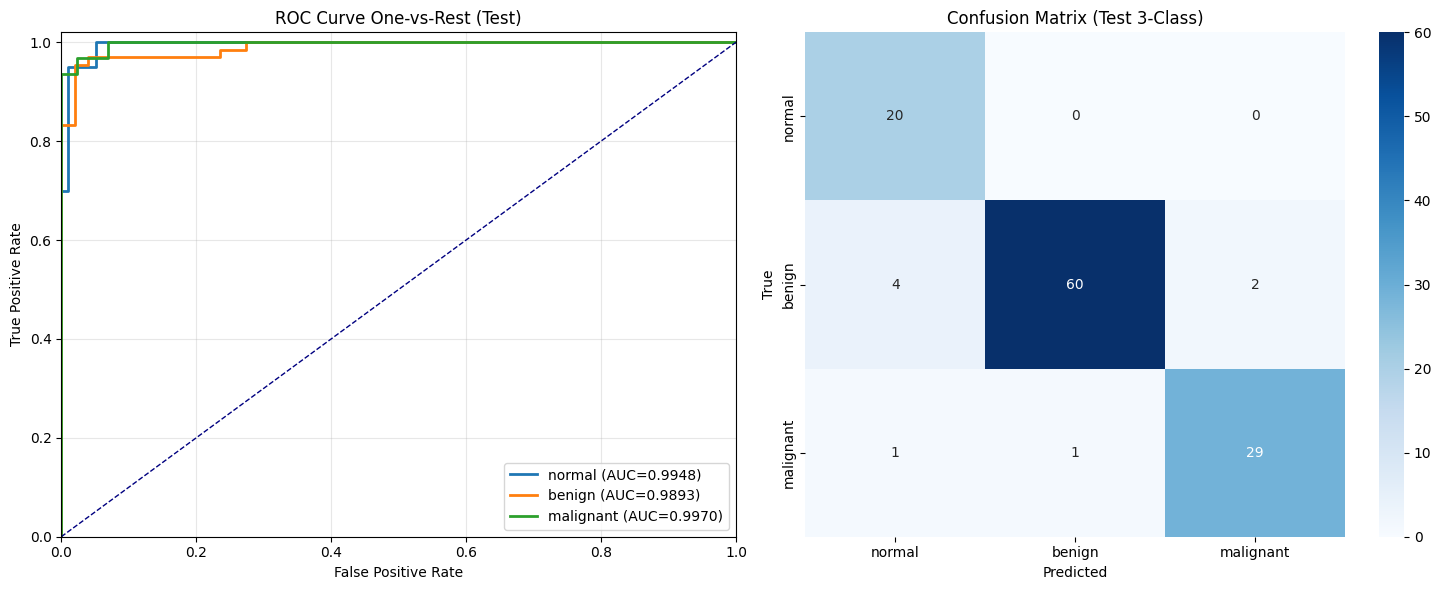

In [ ]:
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

class_names = ['normal', 'benign', 'malignant']
for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve((y_true == i).astype(int), y_prob[:, i])
    auc_i = roc_auc_score((y_true == i).astype(int), y_prob[:, i])
    axes[0].plot(fpr, tpr, lw=2, label=f'{class_name} (AUC={auc_i:.4f})')

axes[0].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve One-vs-Rest (Test)')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1],
    xticklabels=class_names,
    yticklabels=class_names,
)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Test 3-Class)')

plt.tight_layout()
plt.savefig(os.path.join(save_root, 'class_2_eval.png'), dpi=150, bbox_inches='tight')
plt.show()